In [1]:
import numpy as np
import pandas as pd
import itertools
import holidays

# Model
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analytics
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.seasonal import STL

# Evaluation
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

d:\100-KULIAH\PYTHON\ml\clear-stocks\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


# Load data

In [2]:
aapl_stock = pd.read_csv('../data/aapl_stock_price.csv', index_col=[0], parse_dates=[0])
aapl_stock.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.347174,24.817059,23.906238,24.805924,212818400
2015-01-05,23.661276,24.195743,23.474213,24.115573,257142000
2015-01-06,23.663504,23.924056,23.300511,23.725858,263188400
2015-01-07,23.995319,24.095531,23.761490,23.872837,160423600
2015-01-08,24.917274,24.975175,24.206879,24.324908,237458000


# Seasonal decompose

In [3]:
def seasonalDecompose(y, period, is_plot=True):
    stl = STL(y, period=period)
    result = stl.fit()
    if is_plot:
        fig = result.plot() 
        fig.set_size_inches(13,6)
        for axes in fig.axes:
            axes.grid(True)
        plt.show()
    return result

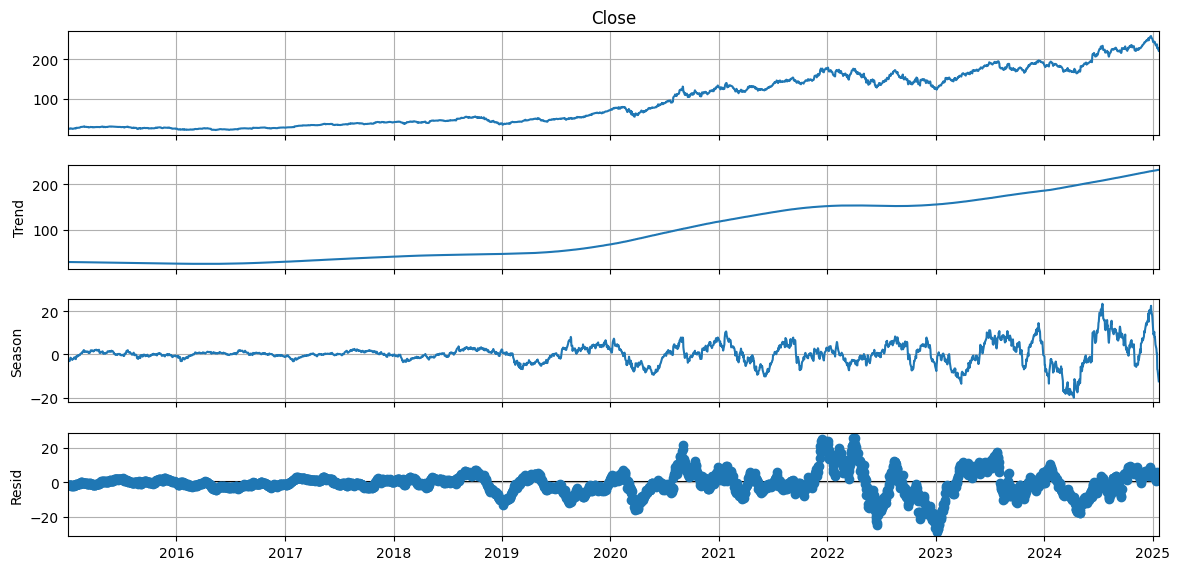

In [4]:
# period = multiples of 5 because working days
a = seasonalDecompose(aapl_stock['Close'], period=260)

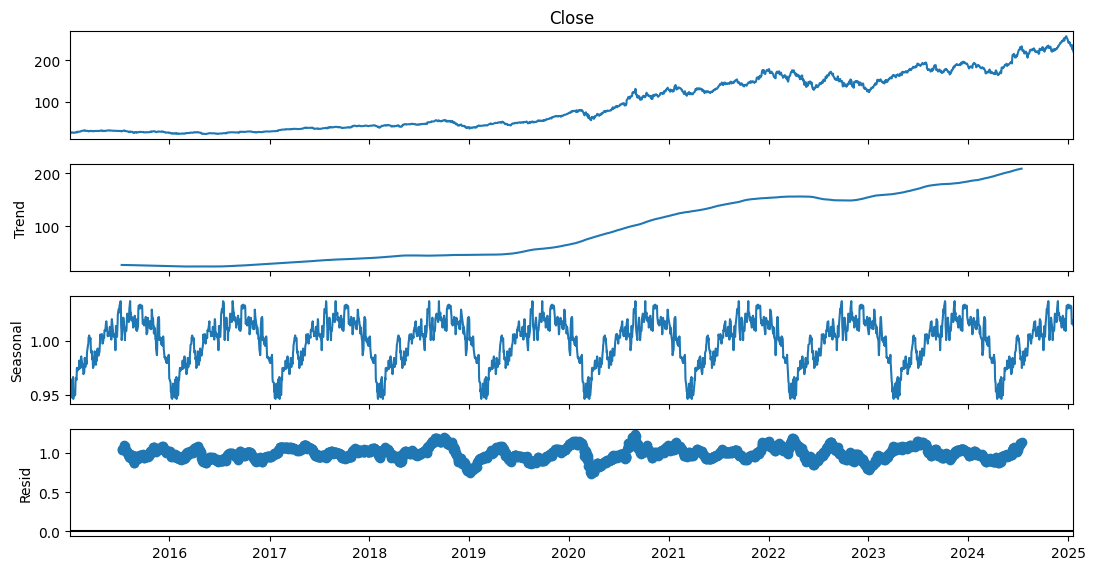

In [5]:
dec = sm.tsa.seasonal_decompose(aapl_stock['Close'], period=260, model='multiplicative').plot().set_size_inches(12,6)
plt.show()

In [6]:
stock = pd.read_csv('../data/aapl_stock_price.csv', parse_dates=[0])

train_data = stock.copy()
train_data = train_data[['Date', "Close"]]
train_data.rename(columns={'Date': 'ds', "Close": 'y'}, inplace=True)

model = Prophet()
model.fit(train_data)

14:18:24 - cmdstanpy - INFO - Chain [1] start processing
14:18:26 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
dates = pd.DataFrame({'ds': aapl_stock.index}).drop_duplicates().sort_values(by='ds')
ds = pd.DataFrame()
ds['ds'] = pd.to_datetime(dates['ds'])
forecast = model.predict(ds)
# additive_terms = weekly + yearly
fcst = forecast[['ds', 'yhat', 'trend', 'additive_terms']]
fcst.head()

,ds,yhat,trend,additive_terms
0,2015-01-02,28.246889,24.623917,3.622973
1,2015-01-05,28.317661,24.593994,3.723667
2,2015-01-06,28.235400,24.584020,3.651379
3,2015-01-07,28.190464,24.574046,3.616417
4,2015-01-08,28.113148,24.564072,3.549076


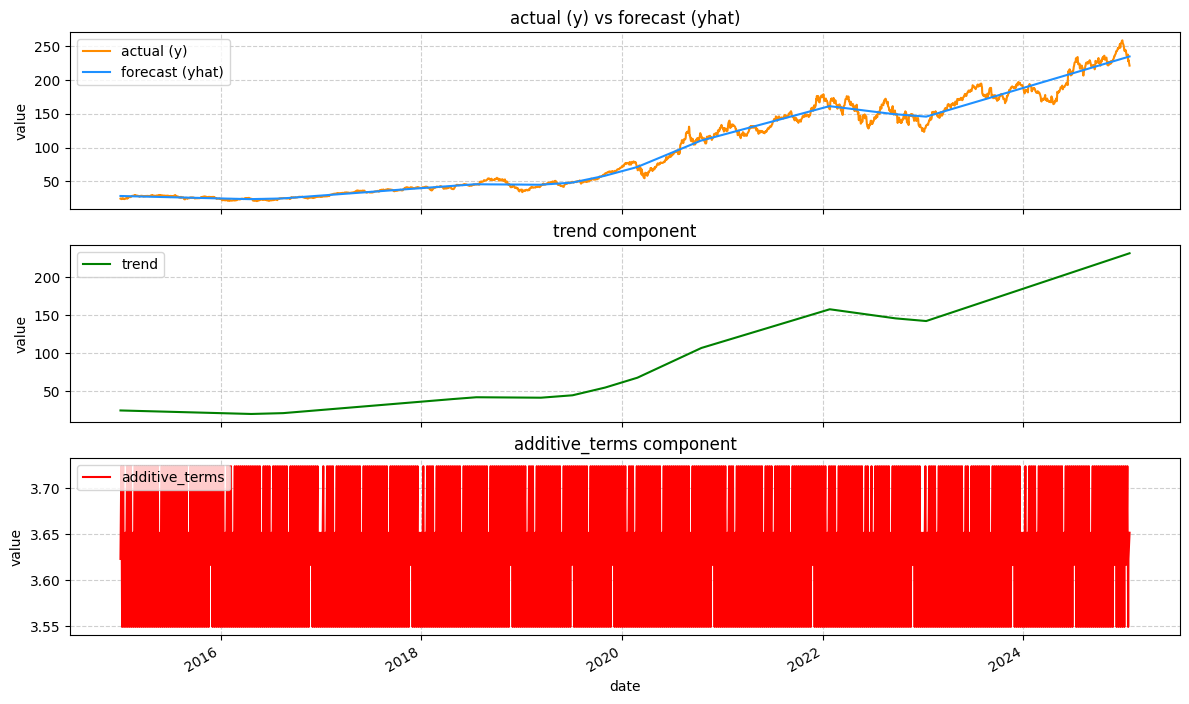

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

# Plot 1: actual 'y' and forecast 'yhat' values overlaid
axes[0].plot(train_data['ds'], train_data['y'], label='actual (y)', color='darkorange')
axes[0].plot(fcst['ds'], fcst['yhat'], label='forecast (yhat)', color='dodgerblue')
axes[0].set_title('actual (y) vs forecast (yhat)')
axes[0].set_ylabel('value')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper left')

# Plot 2: trend values (shifted to axes[1])
axes[1].plot(fcst['ds'], fcst['trend'], label='trend', color='green')
axes[1].set_title('trend component')
axes[1].set_ylabel('value')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper left')

# Plot 3: additive_terms values (shifted to axes[2])
axes[2].plot(fcst['ds'], fcst['additive_terms'], label='additive_terms', color='red')
axes[2].set_title('additive_terms component')
axes[2].set_ylabel('value')
axes[2].set_xlabel('date') # x-label now on the bottom plot
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper left')

plt.tight_layout()
fig.autofmt_xdate()
plt.show()

# Train test split

In [9]:
def train_test_split(data, split_date):
    train = data[data.index < split_date]
    test = data[data.index >= split_date]
    return train, test

# Define split date
start_date = aapl_stock.index[0]
split_index = round(len(aapl_stock) * 0.8)
split_date = aapl_stock.index[split_index] 

aapl_close_train, aapl_close_test = train_test_split(aapl_stock["Close"], split_date)

# Helper funcs

In [10]:
def get_split_date(data, train_percent):
    split_index = round(len(data) * train_percent)
    split_date = data.index[split_index] 

    return split_date

def get_holidays(country, years):
    """
    This function retrieves holiday data for a specific country and range of years.
    Args:
     - country: The country code for which to retrieve holidays (e.g., 'US').
     - years: A range or list of years to retrieve holidays for.
    Return: A DataFrame containing holiday names and dates.
    """
    country_holidays = holidays.country_holidays(country, years=years)
    holiday_list = pd.DataFrame({
        'holiday': list(country_holidays.values()),
        'ds': list(country_holidays.keys()),
    })
    holiday_list['ds'] = pd.to_datetime(holiday_list['ds'])
    return holiday_list

def get_prophet(data, column, period=365.25, holidays=None, cps=0.05, sps=10, hps=10, seasm='additive', cpr=0.8, year_fourier_term=10):
    """
    This function trains a Prophet model on the given data and incorporates holidays.
    Args:
     - data: A DataFrame containing the time series data.
     - column: The name of the column to predict.
     - holidays: A DataFrame of holiday information with columns 'ds' and 'holiday'.
    Return: A trained Prophet model.
    """
    df_train = data.copy()
    df_train['date'] = df_train.index
    df_train = df_train[['date', column]]
    df_train.rename(columns={'date': 'ds', column: 'y'}, inplace=True)
    
    my_model = Prophet(
        holidays=holidays,
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        holidays_prior_scale=hps,
        seasonality_mode=seasm,
        changepoint_range=cpr,
        yearly_seasonality=year_fourier_term,
        period=period
    )
    my_model.fit(df_train)
    
    return my_model

def get_prepared_data(data, column):
    df_train = data.copy()
    df_train['date'] = df_train.index
    df_train = df_train[['date', column]]
    df_train.rename(columns={'date': 'ds', column: 'y'}, inplace=True)
    
    return df_train

def plot_prophet_components(data, model):
    stock = data

    train_data = stock.copy()
    train_data = train_data[['Date', "Close"]]
    train_data.rename(columns={'Date': 'ds', "Close": 'y'}, inplace=True)

    dates = pd.DataFrame({'ds': aapl_stock.index}).drop_duplicates().sort_values(by='ds')
    ds = pd.DataFrame()
    ds['ds'] = pd.to_datetime(dates['ds'])
    forecast = model.predict(ds)
    # additive_terms = weekly + yearly
    fcst = forecast[['ds', 'yhat', 'trend', 'additive_terms']]

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

    # Plot 1: actual 'y' and forecast 'yhat' values
    axes[0].plot(train_data['ds'], train_data['y'], label='actual (y)', color='darkorange')
    axes[0].plot(fcst['ds'], fcst['yhat'], label='forecast (yhat)', color='dodgerblue')
    axes[0].set_title('actual (y) vs forecast (yhat)')
    axes[0].set_ylabel('value')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(loc='upper left')

    # Plot 2: trend values
    axes[1].plot(fcst['ds'], fcst['trend'], label='trend', color='green')
    axes[1].set_title('trend component')
    axes[1].set_ylabel('value')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(loc='upper left')

    # Plot 3: additive_terms values
    axes[2].plot(fcst['ds'], fcst['additive_terms'], label='additive_terms', color='red')
    axes[2].set_title('additive_terms component')
    axes[2].set_ylabel('value')
    axes[2].set_xlabel('date')
    axes[2].grid(True, linestyle='--', alpha=0.6)
    axes[2].legend(loc='upper left')

    plt.tight_layout()
    fig.autofmt_xdate()
    plt.show()

def plot_prophet_components_mult(data, model):
    stock = data

    train_data = stock.copy()
    train_data = train_data[['Date', "Close"]]
    train_data.rename(columns={'Date': 'ds', "Close": 'y'}, inplace=True)

    dates = pd.DataFrame({'ds': aapl_stock.index}).drop_duplicates().sort_values(by='ds')
    ds = pd.DataFrame()
    ds['ds'] = pd.to_datetime(dates['ds'])
    forecast = model.predict(ds)
    # additive_terms = weekly + yearly
    fcst = forecast[['ds', 'yhat', 'trend', 'multiplicative_terms']]

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

    # Plot 1: actual 'y' and forecast 'yhat' values
    axes[0].plot(train_data['ds'], train_data['y'], label='actual (y)', color='darkorange')
    axes[0].plot(fcst['ds'], fcst['yhat'], label='forecast (yhat)', color='dodgerblue')
    axes[0].set_title('actual (y) vs forecast (yhat)')
    axes[0].set_ylabel('value')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(loc='upper left')

    # Plot 2: trend values
    axes[1].plot(fcst['ds'], fcst['trend'], label='trend', color='green')
    axes[1].set_title('trend component')
    axes[1].set_ylabel('value')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(loc='upper left')

    # Plot 3: multiplicative_terms values
    axes[2].plot(fcst['ds'], fcst['multiplicative_terms'], label='multiplicative_terms', color='red')
    axes[2].set_title('multiplicative_terms component')
    axes[2].set_ylabel('value')
    axes[2].set_xlabel('date')
    axes[2].grid(True, linestyle='--', alpha=0.6)
    axes[2].legend(loc='upper left')

    plt.tight_layout()
    fig.autofmt_xdate()
    plt.show()

def plot_prophet_and_sm_components(data, model, sm_period=260): # Added sm_period parameter
    """
    Plots Prophet forecast components and overlays statsmodels seasonal decomposition.

    Args:
        data (pd.DataFrame): DataFrame with 'Date' (index or column) and 'Close' column.
                             Assumes 'Date' is convertible to datetime.
        model: Trained Prophet model instance.
        sm_period (int): The period to use for statsmodels seasonal_decompose.
    """
    stock = data.copy() # Work on a copy

    # Ensure 'Date' is the index for seasonal_decompose compatibility
    if 'Date' in stock.columns:
        stock.set_index('Date', inplace=True)
    stock.index = pd.to_datetime(stock.index) # Ensure index is datetime

    # --- Statsmodels Decomposition ---
    # Ensure data has sufficient length for the period
    if len(stock) > sm_period * 2: # Rule of thumb: need at least 2 full periods
        decomposition_result = sm.tsa.seasonal_decompose(stock['Close'], period=sm_period, model='additive')
        seasonal_sm = decomposition_result.seasonal
    else:
        print(f"Warning: Data length ({len(stock)}) is too short for period {sm_period}. Skipping statsmodels plot.")
        seasonal_sm = None # Set to None if decomposition can't be done reliably

    # --- Prophet Preparation ---
    train_data = stock.reset_index().copy() # Get 'Date' back as a column for Prophet
    train_data = train_data[['Date', "Close"]]
    train_data.rename(columns={'Date': 'ds', "Close": 'y'}, inplace=True)

    # Use dates from the original data for prediction to align axes
    ds = pd.DataFrame({'ds': pd.to_datetime(stock.index)})
    forecast = model.predict(ds)
    # additive_terms = weekly + yearly + holidays + custom regressors (if any)
    fcst = forecast[['ds', 'yhat', 'trend', 'additive_terms']]

    # --- Plotting ---
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True) # Adjusted figsize slightly

    # Plot 1: actual 'y' and forecast 'yhat' values
    axes[0].plot(train_data['ds'], train_data['y'], label='actual (y)', color='darkorange')
    axes[0].plot(fcst['ds'], fcst['yhat'], label='forecast (yhat)', color='dodgerblue')
    axes[0].set_title('actual (y) vs forecast (yhat)')
    axes[0].set_ylabel('value')
    axes[0].grid(True, alpha=0.6)
    axes[0].legend(loc='upper left')

    # Plot 2: trend values
    axes[1].plot(fcst['ds'], fcst['trend'], label='Prophet trend', color='green') # Clarified label
    # Optionally plot statsmodels trend too if desired
    # if seasonal_sm is not None:
    #    axes[1].plot(decomposition_result.trend.index, decomposition_result.trend.values, label='Statsmodels trend', color='limegreen', linestyle=':')
    axes[1].set_title('trend component')
    axes[1].set_ylabel('value')
    axes[1].grid(True, alpha=0.6)
    axes[1].legend(loc='upper left')

    # Plot 3: additive_terms values (Prophet) vs Seasonal (Statsmodels)
    axes[2].plot(fcst['ds'], fcst['additive_terms'], label='Prophet additive_terms', color='purple')
    if seasonal_sm is not None:
        # Plot statsmodels seasonal component - its index should align if ds covers the original range
        axes[2].plot(seasonal_sm.index, seasonal_sm.values, label=f'Statsmodels seasonal (period={sm_period})', color='red')
    axes[2].set_title('Prophet additive_terms vs Statsmodels seasonal component') # Updated title
    axes[2].set_ylabel('value')
    axes[2].set_xlabel('date')
    axes[2].grid(True, alpha=0.6)
    axes[2].legend(loc='upper left')

    plt.tight_layout()
    fig.autofmt_xdate()
    plt.show()

# Dates (ds) dataframe

In [11]:
train_dates = pd.DataFrame({'ds': aapl_close_train.index})
test_dates = pd.DataFrame({'ds': aapl_close_test.index})
future_dates = pd.concat([train_dates, test_dates]).drop_duplicates().sort_values(by='ds')
future_dates['ds'] = pd.to_datetime(future_dates['ds'])

# Basic model
With holidays

12:27:36 - cmdstanpy - INFO - Chain [1] start processing
12:27:37 - cmdstanpy - INFO - Chain [1] done processing


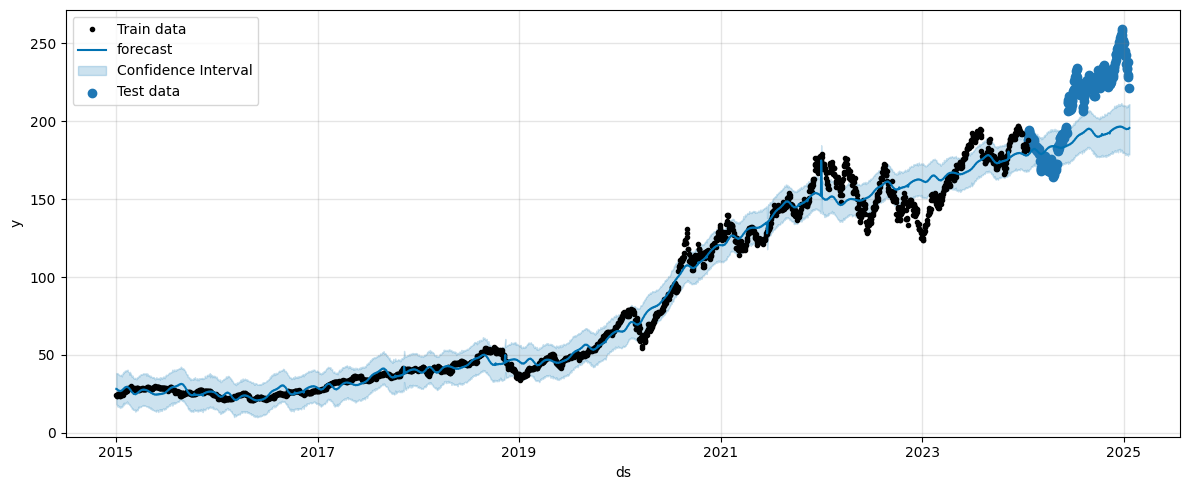

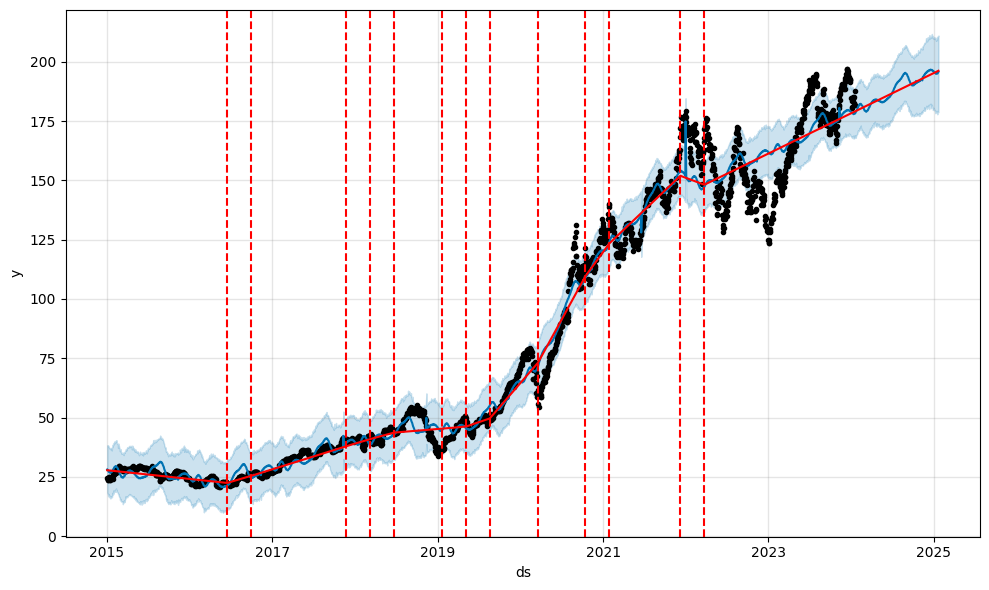

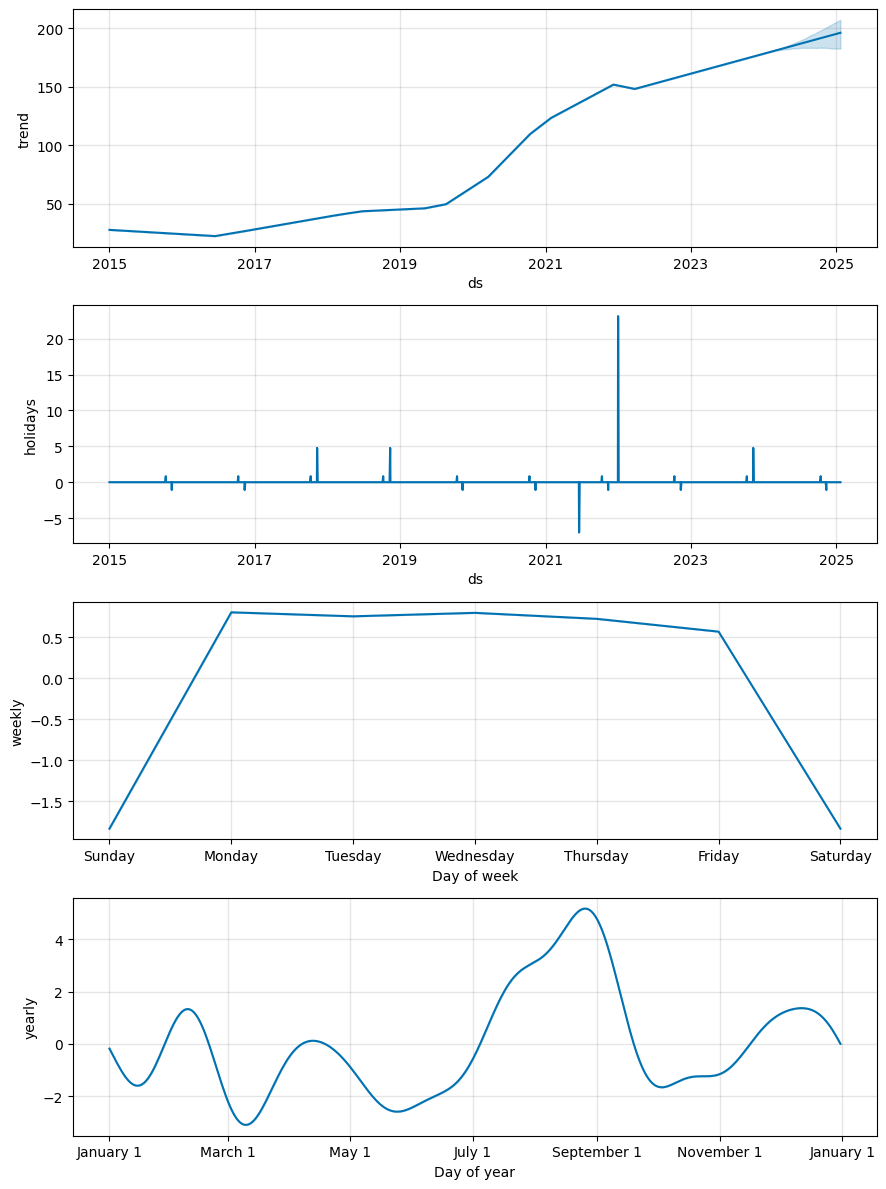

In [13]:
spld = get_split_date(aapl_stock, 0.9)

holidays_data = get_holidays('US', years=range(2015, 2026))
model_close = get_prophet(data=aapl_stock[:spld], column='Close', holidays=holidays_data)

forecast = model_close.predict(future_dates)
model_close.plot(forecast, uncertainty=True, figsize=(12,5))
plt.scatter(aapl_stock[spld:].index, aapl_stock['Close'][spld:])
plt.legend(['Train data', 'forecast', 'Confidence Interval', 'Test data'], loc='upper left')

fig = model_close.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model_close, forecast)

fig2 = model_close.plot_components(forecast)

In [14]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast['yhat'][forecast['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast['yhat'][forecast['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast['yhat'][forecast['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 22.46180778320119 | MAE : 17.2296366481079, | MAPE : 0.08420158269091144


# Hyperparameter tuning

Parameters that can be tuned

1. `changepoint_prior_scale` (CPS): This is probably the most impactful parameter. It determines the flexibility of the trend, and in particular how much the trend changes at the trend changepoints. As described in this documentation, if it is too small, the trend will be underfit and variance that should have been modeled with trend changes will instead end up being handled with the noise term. If it is too large, the trend will overfit and in the most extreme case you can end up with the trend capturing yearly seasonality. The default of 0.05 works for many time series, but this could be tuned; a range of [0.001, 0.5] would likely be about right. Parameters like this (regularization penalties; this is effectively a lasso penalty) are often tuned on a log scale.
2. `seasonality_prior_scale` (SPS): This parameter controls the flexibility of the seasonality. Similarly, a large value allows the seasonality to fit large fluctuations, a small value shrinks the magnitude of the seasonality. The default is 10., which applies basically no regularization. That is because we very rarely see overfitting here (there’s inherent regularization with the fact that it is being modeled with a truncated Fourier series, so it’s essentially low-pass filtered). A reasonable range for tuning it would probably be [0.01, 10]; when set to 0.01 you should find that the magnitude of seasonality is forced to be very small. This likely also makes sense on a log scale, since it is effectively an L2 penalty like in ridge regression.
3. `holidays_prior_scale` (HPS): This controls flexibility to fit holiday effects. Similar to seasonality_prior_scale, it defaults to 10.0 which applies basically no regularization, since we usually have multiple observations of holidays and can do a good job of estimating their effects. This could also be tuned on a range of [0.01, 10] as with seasonality_prior_scale.
4. `seasonality_mode` (SEASM): Options are ['additive', 'multiplicative']. Default is 'additive', but many business time series will have multiplicative seasonality. This is best identified just from looking at the time series and seeing if the magnitude of seasonal fluctuations grows with the magnitude of the time series (see the documentation here on multiplicative seasonality), but when that isn’t possible, it could be tuned.


In [73]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1, 10],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(get_prepared_data(data=aapl_stock[:split_date], column='Close'))  # Fit model with given params
    df_cv = cross_validation(m, initial='2275 days', period='252 days', horizon = '1 days', parallel='processes')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
print(tuning_results)

20:21:57 - cmdstanpy - INFO - Chain [1] start processing
20:21:57 - cmdstanpy - INFO - Chain [1] done processing
20:21:59 - cmdstanpy - INFO - Chain [1] start processing
20:21:59 - cmdstanpy - INFO - Chain [1] done processing
20:22:00 - cmdstanpy - INFO - Chain [1] start processing
20:22:00 - cmdstanpy - INFO - Chain [1] done processing
20:22:02 - cmdstanpy - INFO - Chain [1] start processing
20:22:02 - cmdstanpy - INFO - Chain [1] done processing
20:22:04 - cmdstanpy - INFO - Chain [1] start processing
20:22:04 - cmdstanpy - INFO - Chain [1] done processing
20:22:05 - cmdstanpy - INFO - Chain [1] start processing
20:22:05 - cmdstanpy - INFO - Chain [1] done processing
20:22:07 - cmdstanpy - INFO - Chain [1] start processing
20:22:07 - cmdstanpy - INFO - Chain [1] done processing
20:22:08 - cmdstanpy - INFO - Chain [1] start processing
20:22:08 - cmdstanpy - INFO - Chain [1] done processing
20:22:10 - cmdstanpy - INFO - Chain [1] start processing
20:22:10 - cmdstanpy - INFO - Chain [1]

     changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale  \
0                      0.001                     0.01                  0.01   
1                      0.001                     0.01                  0.01   
2                      0.001                     0.01                  0.10   
3                      0.001                     0.01                  0.10   
4                      0.001                     0.01                  1.00   
..                       ...                      ...                   ...   
123                    0.500                    10.00                  0.10   
124                    0.500                    10.00                  1.00   
125                    0.500                    10.00                  1.00   
126                    0.500                    10.00                 10.00   
127                    0.500                    10.00                 10.00   

    seasonality_mode       rmse  
0           addit

In [ ]:
best_params = all_params[np.argmin(rmses)]
print(best_params)
print(np.min(rmses))

{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'additive'}
14.606521662183962


# Tuned models

## No holidays

Holidays set to None; there is no apparent effect holiday has on the forecast

20:54:27 - cmdstanpy - INFO - Chain [1] start processing
20:54:28 - cmdstanpy - INFO - Chain [1] done processing


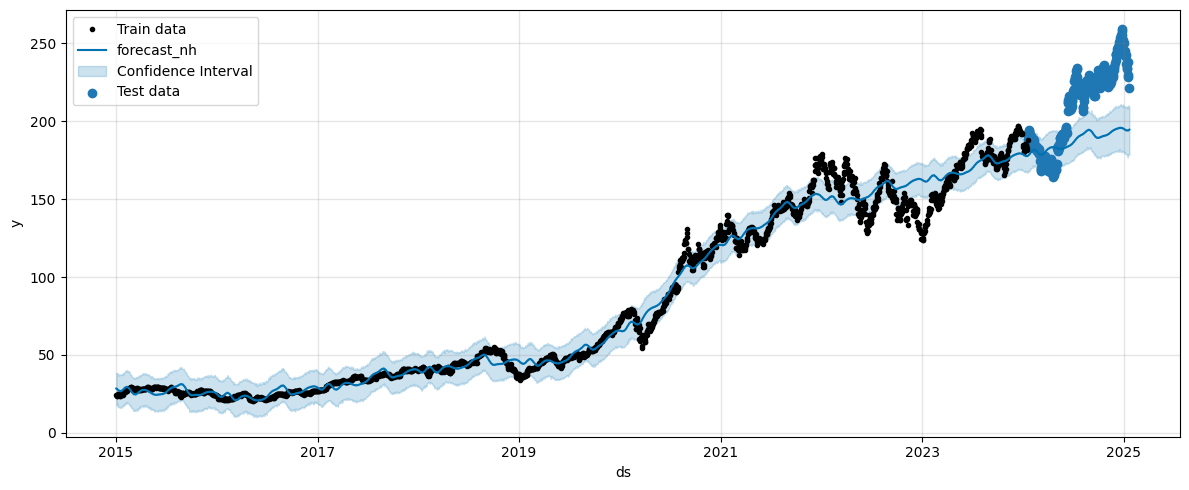

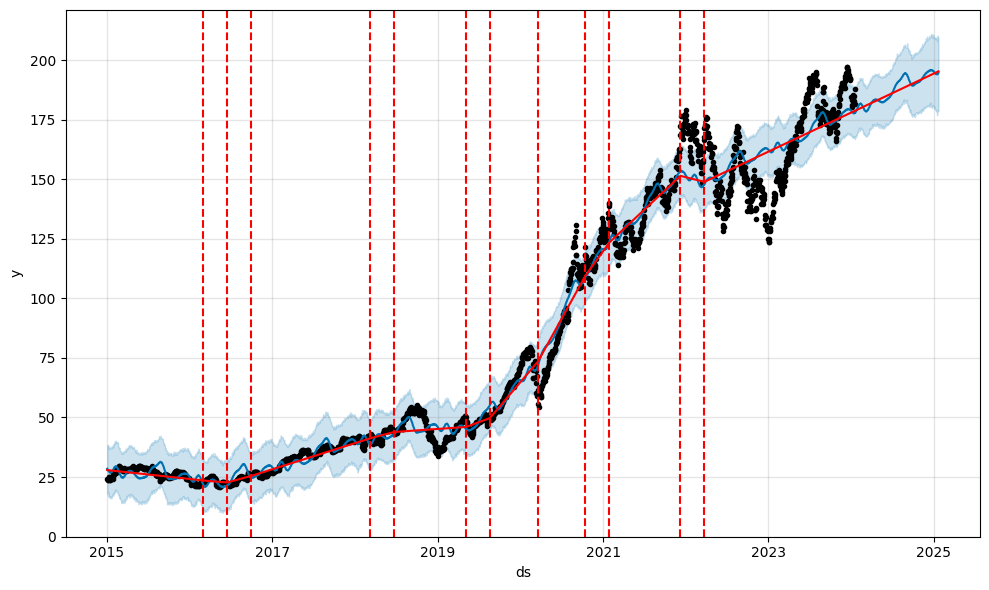

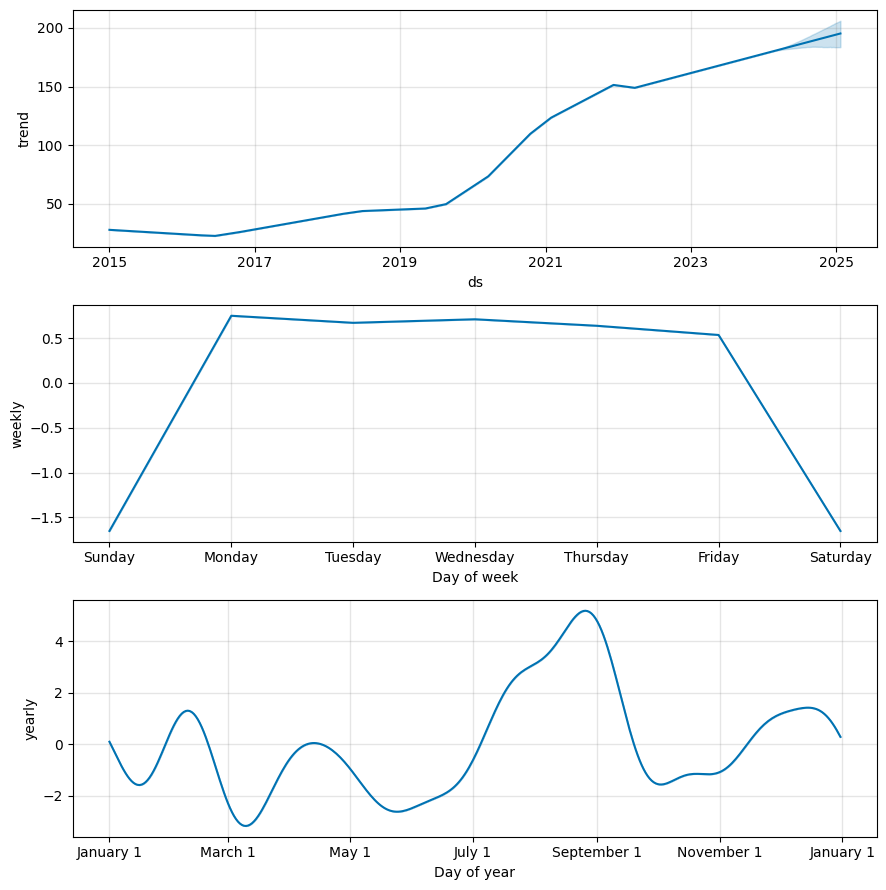

In [113]:
spld = get_split_date(aapl_stock, 0.9)

model_close_nh = get_prophet(data=aapl_stock[:spld], column='Close', holidays=None, cps=0.05, sps=1, seasm='additive')

forecast_nh = model_close_nh.predict(future_dates)
model_close_nh.plot(forecast_nh, uncertainty=True, figsize=(12,5))
plt.scatter(aapl_stock[spld:].index, aapl_stock['Close'][spld:])
plt.legend(['Train data', 'forecast_nh', 'Confidence Interval', 'Test data'], loc='upper left')

fig = model_close_nh.plot(forecast_nh)
a = add_changepoints_to_plot(fig.gca(), model_close_nh, forecast_nh)

fig2 = model_close_nh.plot_components(forecast_nh)

In [114]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast_nh['yhat'][forecast_nh['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast_nh['yhat'][forecast_nh['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast_nh['yhat'][forecast_nh['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 22.84422401686863 | MAE : 17.5034968759021, | MAPE : 0.08542856092025254


## Best params 1
initial='2260 days', period='260 days', horizon = '1 days'

20:54:29 - cmdstanpy - INFO - Chain [1] start processing
20:54:30 - cmdstanpy - INFO - Chain [1] done processing


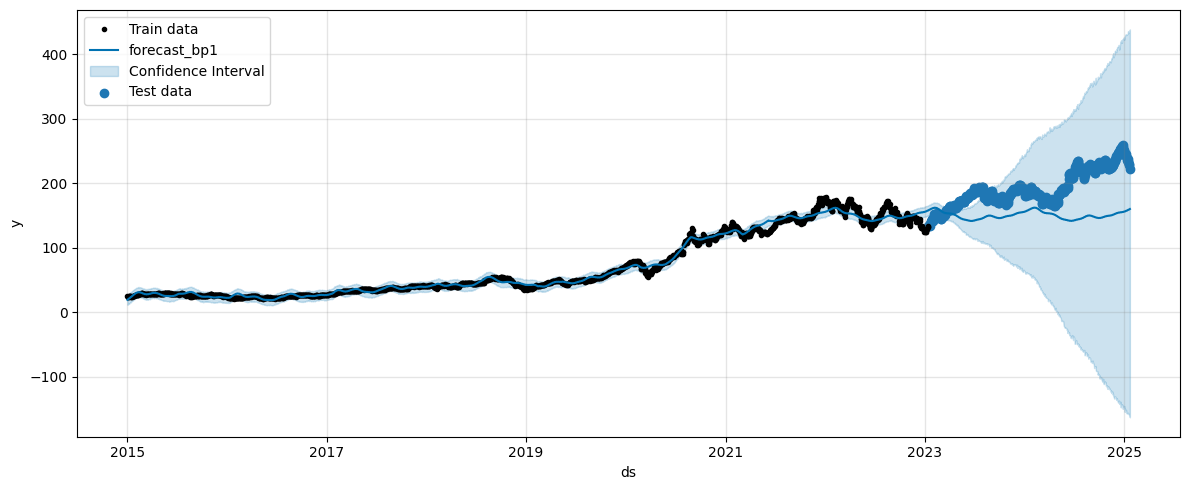

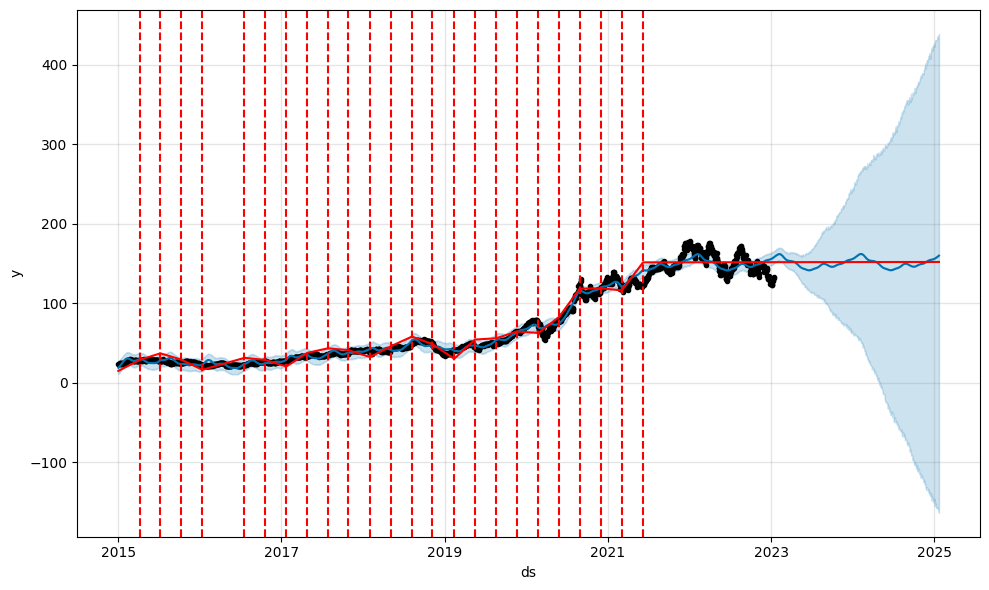

In [115]:
model_bp1 = get_prophet(data=aapl_stock[:split_date], column='Close', holidays=None, cps=0.5, sps=10, hps=0.01, seasm='additive')

forecast_bp1 = model_bp1.predict(future_dates)
model_bp1.plot(forecast_bp1, uncertainty=True, figsize=(12,5))
plt.scatter(aapl_stock[split_date:].index, aapl_stock['Close'][split_date:])
plt.legend(['Train data', 'forecast_bp1', 'Confidence Interval', 'Test data'], loc='upper left')

fig = model_bp1.plot(forecast_bp1)
a = add_changepoints_to_plot(fig.gca(), model_bp1, forecast_bp1)

In [116]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast_bp1['yhat'][forecast_bp1['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast_bp1['yhat'][forecast_bp1['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast_bp1['yhat'][forecast_bp1['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 50.39218740368419 | MAE : 42.7991787929734, | MAPE : 0.20961854187851992


## Best params 2
initial='1896 days', period='632 days', horizon = '1 days'

20:54:31 - cmdstanpy - INFO - Chain [1] start processing
20:54:32 - cmdstanpy - INFO - Chain [1] done processing


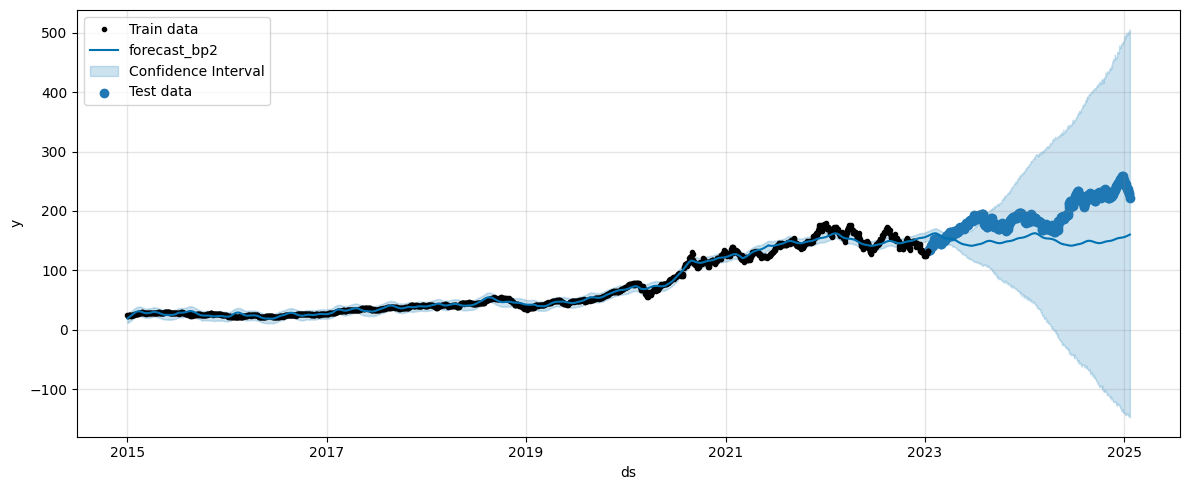

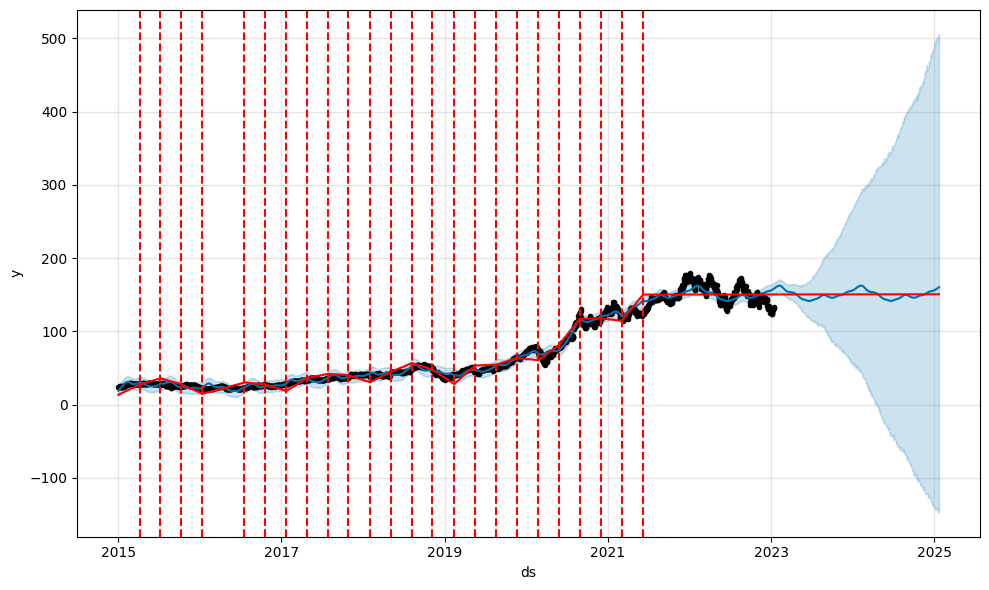

In [117]:
model_bp2 = get_prophet(data=aapl_stock[:split_date], column='Close', holidays=None, cps=0.5, sps=1, hps=0.01, seasm='additive')

forecast_bp2 = model_bp2.predict(future_dates)
model_bp2.plot(forecast_bp2, uncertainty=True, figsize=(12,5))
plt.scatter(aapl_stock[split_date:].index, aapl_stock['Close'][split_date:])
plt.legend(['Train data', 'forecast_bp2', 'Confidence Interval', 'Test data'], loc='upper left')

fig = model_bp2.plot(forecast_bp2)
a = add_changepoints_to_plot(fig.gca(), model_bp2, forecast_bp2)

In [118]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast_bp2['yhat'][forecast_bp2['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast_bp2['yhat'][forecast_bp2['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast_bp2['yhat'][forecast_bp2['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 50.46645110655658 | MAE : 42.8605839159681, | MAPE : 0.20994970135406685


## Best params 3
initial='2022 days', period='506 days', horizon = '1 days'

20:54:32 - cmdstanpy - INFO - Chain [1] start processing
20:54:33 - cmdstanpy - INFO - Chain [1] done processing


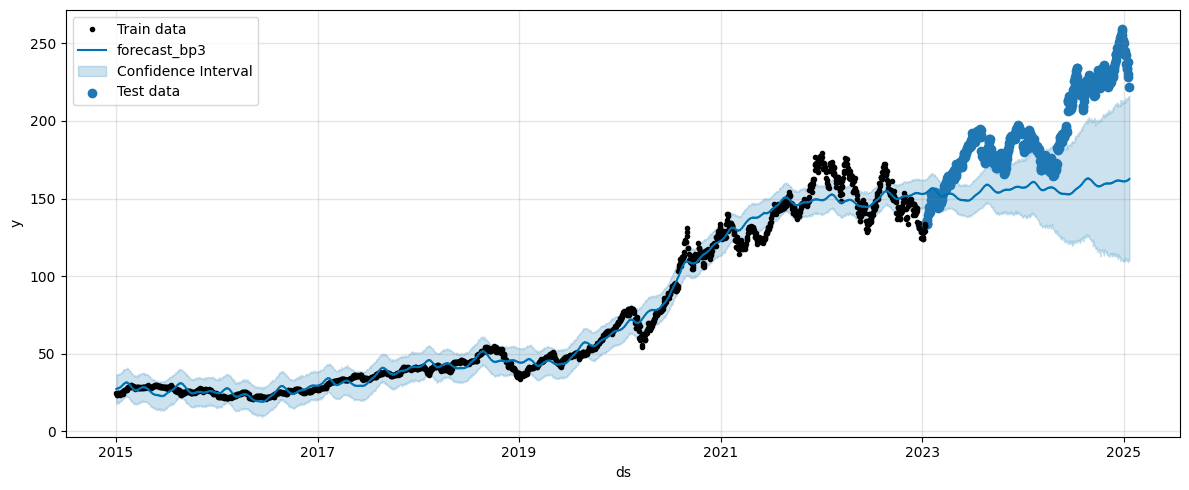

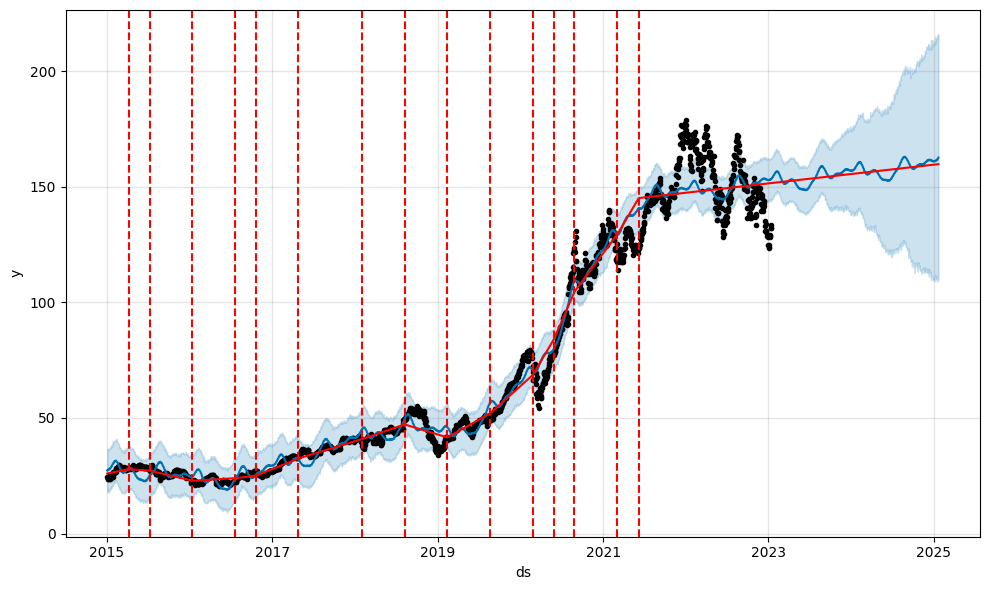

In [119]:
model_bp3 = get_prophet(data=aapl_stock[:split_date], column='Close', holidays=None, cps=0.1, sps=10, hps=0.01, seasm='additive', cpr=0.8)

forecast_bp3 = model_bp3.predict(future_dates)
model_bp3.plot(forecast_bp3, uncertainty=True, figsize=(12,5))
plt.scatter(aapl_stock[split_date:].index, aapl_stock['Close'][split_date:])
plt.legend(['Train data', 'forecast_bp3', 'Confidence Interval', 'Test data'], loc='upper left')

fig = model_bp3.plot(forecast_bp3)
a = add_changepoints_to_plot(fig.gca(), model_bp3, forecast_bp3)

In [120]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast_bp3['yhat'][forecast_bp3['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast_bp3['yhat'][forecast_bp3['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast_bp3['yhat'][forecast_bp3['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 43.60304080200839 | MAE : 36.40479900013063, | MAPE : 0.17714147127836372


## Best params 4
initial='2275 days', period='252 days', horizon = '1 days'

12:35:13 - cmdstanpy - INFO - Chain [1] start processing
12:35:16 - cmdstanpy - INFO - Chain [1] done processing


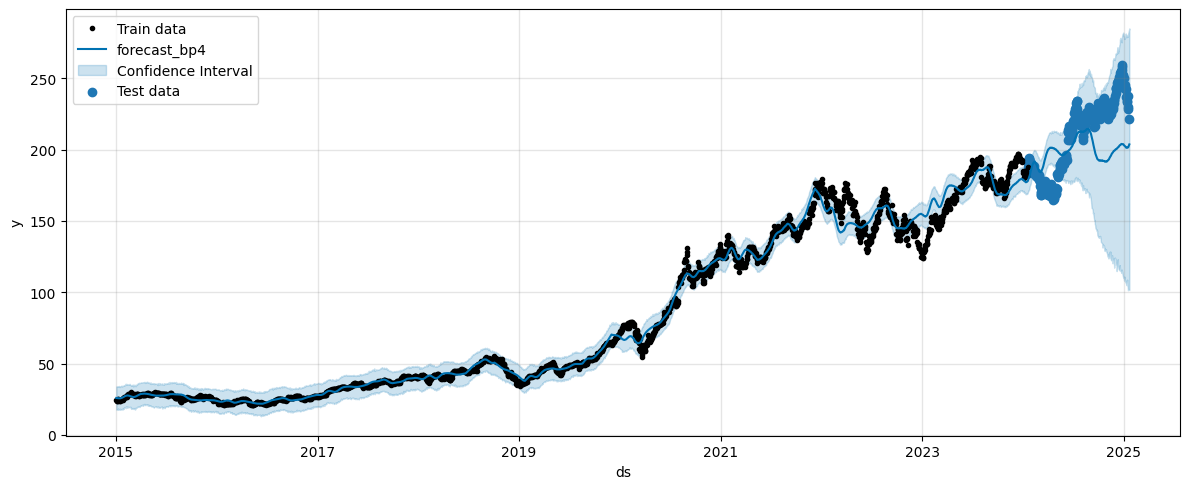

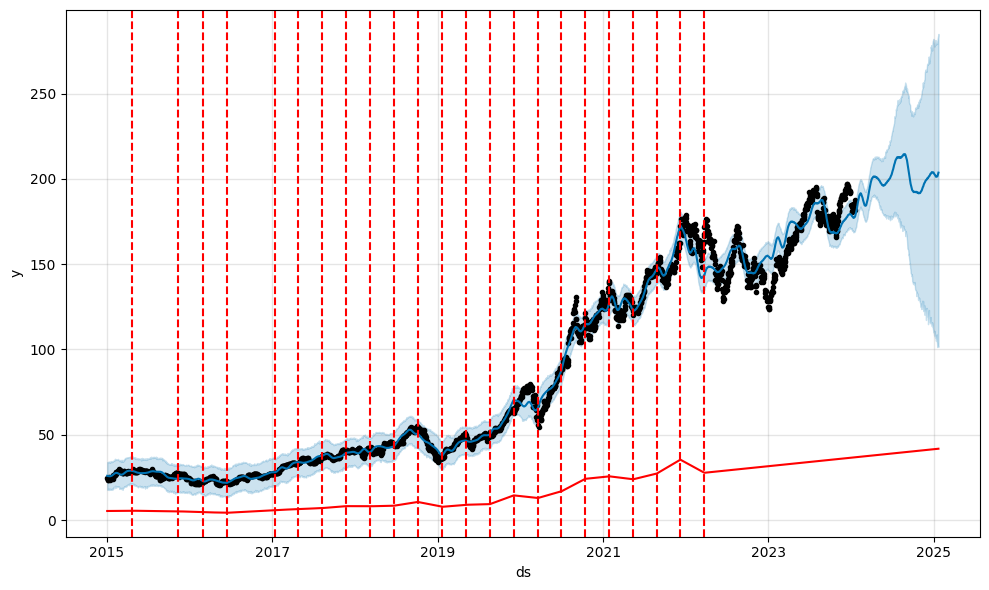

In [19]:
spld = get_split_date(aapl_stock, 0.9)

model_bp4 = get_prophet(data=aapl_stock[:spld], column='Close', holidays=None, cps=0.1, sps=10, hps=0.01, seasm='multiplicative', cpr=0.8)

forecast_bp4 = model_bp4.predict(future_dates)
model_bp4.plot(forecast_bp4, uncertainty=True, figsize=(12,5))
plt.scatter(aapl_stock[spld:].index, aapl_stock['Close'][spld:])
plt.legend(['Train data', 'forecast_bp4', 'Confidence Interval', 'Test data'], loc='upper left')

fig = model_bp4.plot(forecast_bp4)
a = add_changepoints_to_plot(fig.gca(), model_bp4, forecast_bp4)

In [20]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast_bp4['yhat'][forecast_bp4['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast_bp4['yhat'][forecast_bp4['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast_bp4['yhat'][forecast_bp4['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 19.874029411208472 | MAE : 15.572340752898645, | MAPE : 0.07873058723927163


In [23]:
print(forecast_bp4.iloc[-1][['trend', 'multiplicative_terms', 'yhat']])

trend                    41.795214
multiplicative_terms      3.872376
yhat                    203.642008
Name: 2527, dtype: object


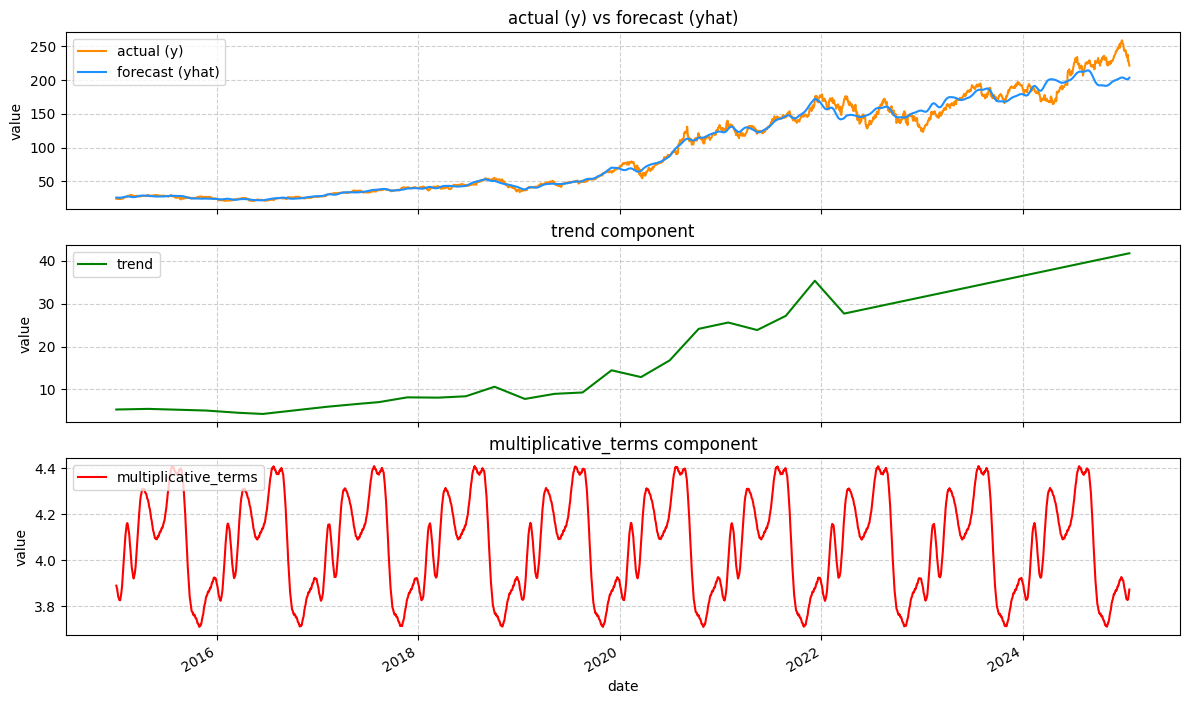

In [26]:
plot_prophet_components_mult(stock, model_bp4)

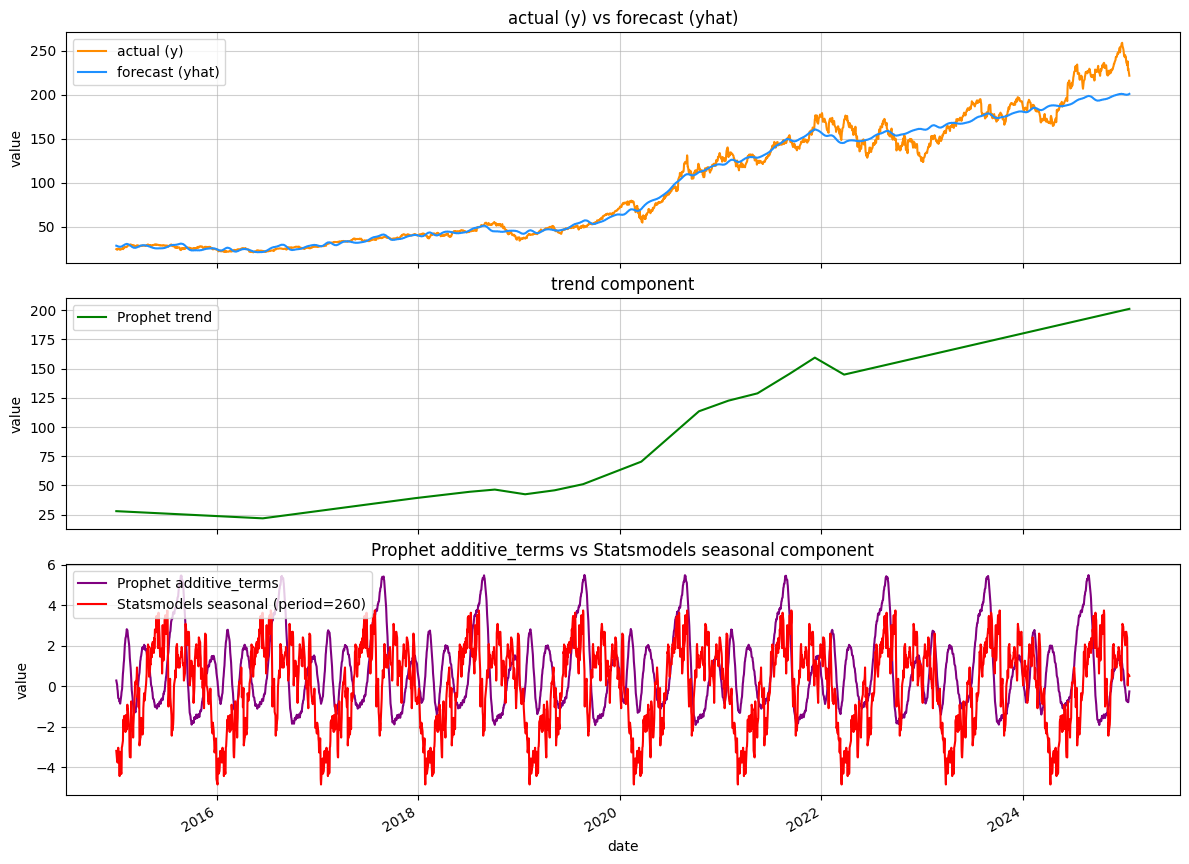

In [125]:
plot_prophet_and_sm_components(stock, model_bp4, sm_period=260)

In [27]:
forecast_bp4

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2015-01-02,5.300734,17.762026,33.969178,5.300734,5.300734,3.889101,3.889101,3.889101,4.064048,4.064048,4.064048,-0.174947,-0.174947,-0.174947,0.0,0.0,0.0,25.915824
1,2015-01-05,5.305215,17.751893,33.977927,5.305215,5.305215,3.874914,3.874914,3.874914,4.071143,4.071143,4.071143,-0.196229,-0.196229,-0.196229,0.0,0.0,0.0,25.862466
2,2015-01-06,5.306708,17.717581,33.922194,5.306708,5.306708,3.864210,3.864210,3.864210,4.067785,4.067785,4.067785,-0.203575,-0.203575,-0.203575,0.0,0.0,0.0,25.812944
3,2015-01-07,5.308202,17.969013,34.195762,5.308202,5.308202,3.859208,3.859208,3.859208,4.069970,4.069970,4.069970,-0.210763,-0.210763,-0.210763,0.0,0.0,0.0,25.793658
4,2015-01-08,5.309696,18.581450,33.967176,5.309696,5.309696,3.848262,3.848262,3.848262,4.065870,4.065870,4.065870,-0.217608,-0.217608,-0.217608,0.0,0.0,0.0,25.742797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2523,2025-01-14,41.699814,104.532070,279.087908,21.866400,57.950655,3.826698,3.826698,3.826698,4.067785,4.067785,4.067785,-0.241087,-0.241087,-0.241087,0.0,0.0,0.0,201.272422
2524,2025-01-15,41.713443,103.675133,279.493883,21.757209,58.073437,3.830232,3.830232,3.830232,4.069970,4.069970,4.069970,-0.239738,-0.239738,-0.239738,0.0,0.0,0.0,201.485621
2525,2025-01-16,41.727072,101.405578,279.400819,21.648017,58.196220,3.829150,3.829150,3.829150,4.065870,4.065870,4.065870,-0.236720,-0.236720,-0.236720,0.0,0.0,0.0,201.506270
2526,2025-01-17,41.740700,102.107924,281.603272,21.538825,58.319002,3.832080,3.832080,3.832080,4.064048,4.064048,4.064048,-0.231969,-0.231969,-0.231969,0.0,0.0,0.0,201.694389


## Best params 5

14:19:55 - cmdstanpy - INFO - Chain [1] start processing
14:19:57 - cmdstanpy - INFO - Chain [1] done processing


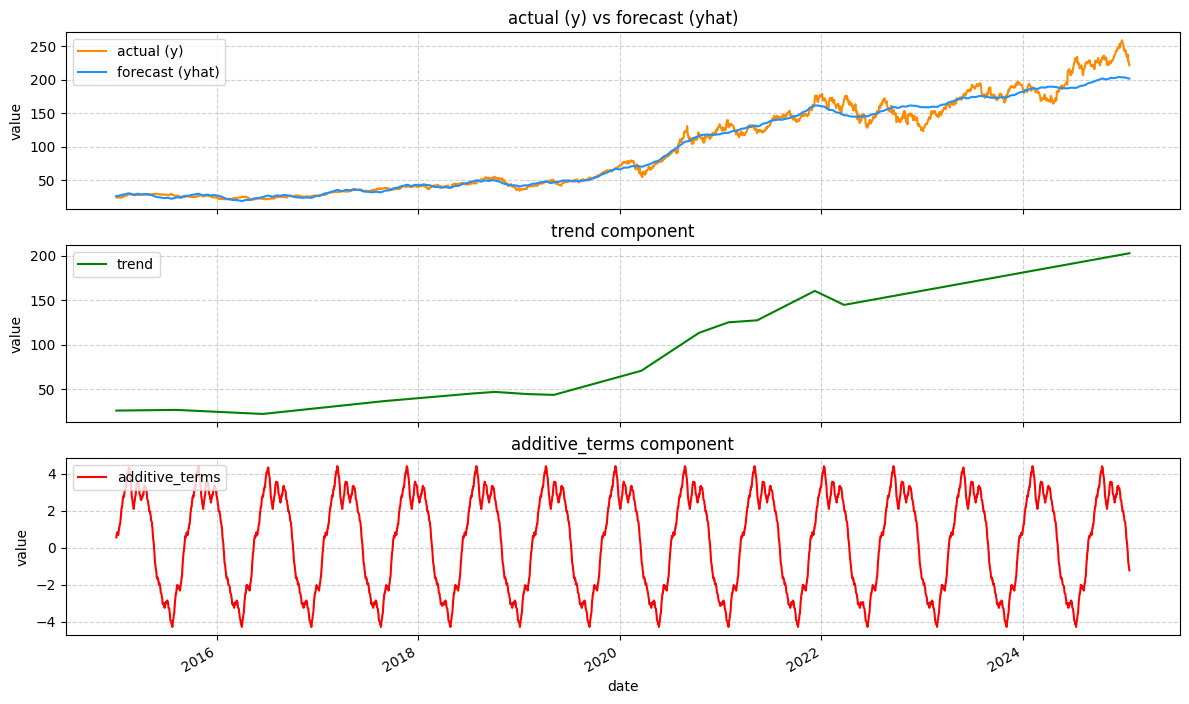

In [18]:
spld = get_split_date(aapl_stock, 0.9)

model_bp4 = get_prophet(data=aapl_stock[:spld], column='Close', period=252, holidays=None, cps=0.1, sps=10, hps=0.01, seasm='additive', cpr=0.8)

forecast_bp4 = model_bp4.predict(future_dates)

plot_prophet_components(stock, model_bp4)

In [19]:
rmse = root_mean_squared_error(aapl_stock[split_date:]['Close'], forecast_bp4['yhat'][forecast_bp4['ds'] >= split_date])
mae = mean_absolute_error(aapl_stock[split_date:]['Close'], forecast_bp4['yhat'][forecast_bp4['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_stock[split_date:]['Close'], forecast_bp4['yhat'][forecast_bp4['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 19.8925127674095 | MAE : 15.444157174413716, | MAPE : 0.0761137993777352


13:39:44 - cmdstanpy - INFO - Chain [1] start processing
13:39:45 - cmdstanpy - INFO - Chain [1] done processing


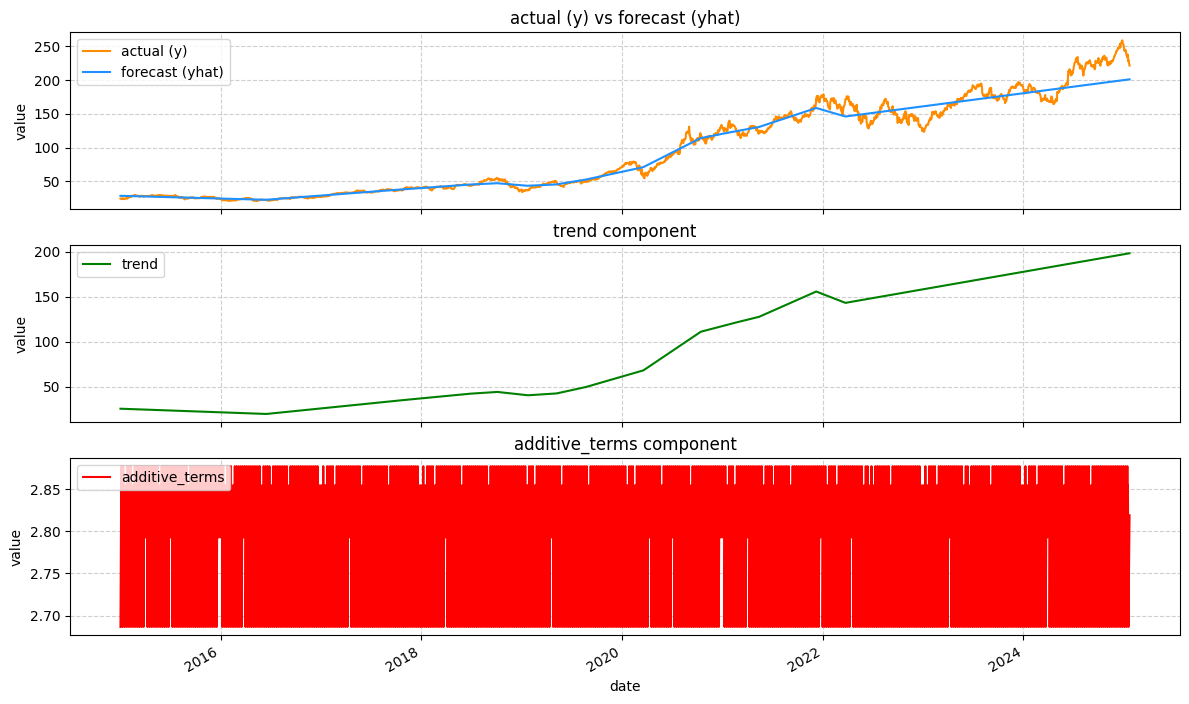

In [34]:
spld = get_split_date(aapl_stock, 0.9)

model_bp4 = get_prophet(data=aapl_stock[:spld], column='Close', holidays=None, cps=0.1, sps=10, hps=0.01, seasm='additive', cpr=0.8, ys=False, ws=10, dailys=False)

forecast_bp4 = model_bp4.predict(future_dates)

plot_prophet_components(stock, model_bp4)